# CHRD Prompt Engine v2

## Amaç

Bu notebook, CHRD-Bench veri kümesindeki metadata bilgilerinden yararlanarak
Stable Diffusion XL ve FLUX modelleri için kültürel olarak doğru,
gerçekçi ve ayrıntılı Türkçe ve İngilizce istemler (promptlar) üretmektedir.

Bu sürümün amacı;

- Gerçek Kapadokya kültürünü korumak,
- Yapay zekâ modellerindeki turistik klişeleri azaltmak,
- DINOv2 benzerlik skorlarını artırmak,
- Gerçek fotoğraflara daha yakın görüntüler oluşturmak,
- Aynı metadata'dan standartlaştırılmış promptlar üretmektir.

# İş Akışı

Bu notebook aşağıdaki adımları gerçekleştirmektedir.

CHRD Metadata

↓

Metadata Temizleme

↓

Bilgi Tabanı

↓

Prompt Motoru

↓

Prompt Kontrolü

↓

TXT / CSV Kaydetme

↓

Stable Diffusion XL

↓

FLUX

# Gerekli Kütüphaneler

In [19]:
import os
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

# Metadata Dosyasının Okunması

In [20]:
df = pd.read_csv(
    "../data/CHRD_Real/metadata_selected.csv",
    sep=";"
)

print("Toplam Görüntü Sayısı :", len(df))

df.head()

Toplam Görüntü Sayısı : 164


,image_id,file_name,theme,location,motif_1,motif_2,season,contains_people,quality_score,cultural_value,notes
0,CHRD_REAL_0001,CHRD_REAL_0001.jpeg,Rock-cut Heritage,Ürgüp,Cave House,Stone House,Summer,No,NaN,High,NaN
1,CHRD_REAL_0004,CHRD_REAL_0004.jpeg,Village Square,Ürgüp,Street,Local People,Summer,No,NaN,Medium,NaN
2,CHRD_REAL_0005,CHRD_REAL_0005.jpeg,Fairy Chimney,NaN,Rock Formation,Balloon,Summer,No,NaN,High,NaN
3,CHRD_REAL_0006,CHRD_REAL_0006.jpeg,Local Architecture,NaN,Church,Monastery,Summer,No,NaN,Low,NaN
4,CHRD_REAL_0007,CHRD_REAL_0007.jpeg,Daily Life,NaN,Stone House,Street,Summer,No,NaN,Medium,NaN


# Metadata Temizleme

Eksik bilgiler "Unknown" değeri ile doldurulmaktadır.

Bu sayede prompt üretimi sırasında hata oluşması engellenmektedir.

In [21]:
columns = [

    "theme",
    "location",
    "motif_1",
    "motif_2",
    "season",
    "contains_people"

]

for col in columns:

    df[col] = (
        df[col]
        .fillna("Unknown")
        .astype(str)
        .str.strip()
    )

print(df.isnull().sum())

image_id             0
file_name            0
theme                0
location             0
motif_1              0
motif_2              0
season               0
contains_people      0
quality_score      164
cultural_value       0
notes              162
dtype: int64


# Tema Bilgi Tabanı

Tema isimleri yalnızca kısa etiketler olarak kullanılmayacaktır.

Her tema, Stable Diffusion modellerinin daha doğru sahne oluşturabilmesi için
ayrıntılı kültürel açıklamalara dönüştürülmektedir.

In [23]:
theme_dict = {

"Daily Life":
"""
Kapadokya'da yaşayan insanların doğal günlük yaşamı,
yerel Anadolu kültürü,
geleneksel yaşam biçimi,
otantik sosyal ortam,
gerçek yaşam sahnesi,
yaşayan kültürel miras
""",

"Rock-cut Heritage":
"""
Kapadokya'nın tarihi kaya oyma mirası,
UNESCO Dünya Mirası,
volkanik tüf kayalara oyulmuş tarihi yapılar,
antik kaya yerleşimleri,
geleneksel Anadolu mimarisi,
otantik tarihi doku,
korunmuş kültürel miras
""",

"Village Square":
"""
Kapadokya köy meydanı,
tarihi taş sokaklar,
yerel mahalle yaşamı,
geleneksel Anadolu yerleşimi,
otantik köy atmosferi,
kültürel yaşam alanı
""",

"Natural Landscape":
"""
Kapadokya'nın doğal manzarası,
vadiler,
volkanik kaya oluşumları,
peri bacaları,
geniş gökyüzü,
otantik doğal çevre
""",

"Local Architecture":
"""
Kapadokya taş mimarisi,
geleneksel kaya evleri,
taş yapılar,
Anadolu mimarisi,
korunmuş tarihi yapılar,
otantik kültürel mimari
"""

}

# Motif Bilgi Tabanı

Her motif ayrıntılı olarak tanımlanmaktadır.

Böylece Stable Diffusion yalnızca nesneyi değil,
nesnenin kültürel bağlamını da öğrenmektedir.

In [24]:
motif_dict = {

"Balloon":
"""
renkli sıcak hava balonları,
Göreme semalarında doğal şekilde süzülen balonlar,
gerçekçi balon uçuşu,
Kapadokya sabah manzarası
""",

"Fairy Chimney":
"""
Kapadokya'ya özgü peri bacaları,
volkanik kaya oluşumları,
doğal jeolojik yapı,
ikonik Kapadokya manzarası
""",

"Cave House":
"""
volkanik kayalara oyulmuş geleneksel kaya evleri,
Kapadokya mağara yerleşimleri,
otantik kaya konutları
""",

"Stone House":
"""
geleneksel taş evler,
Anadolu taş mimarisi,
tarihi taş yapılar
""",

"Church":
"""
tarihi kaya kilisesi,
Bizans dönemi kaya kilisesi,
otantik dini mimari
""",

"Monastery":
"""
antik kaya manastırı,
tarihi dini yapı,
Kapadokya manastırı
""",

"Museum":
"""
yerel kültür müzesi,
tarihi eser koleksiyonu,
kültürel miras müzesi
""",

"Pottery":
"""
Avanos el yapımı çömlek sanatı,
kırmızı kil seramikleri,
geleneksel çömlek ustalığı
""",

"Street":
"""
tarihi taş sokak,
otantik Kapadokya yolu,
geleneksel mahalle yolu
""",

"River":
"""
Kızılırmak Nehri,
doğal nehir manzarası,
nehir kıyısı
""",

"Landscape":
"""
Kapadokya doğal manzarası,
geniş açık arazi,
otantik doğa görünümü
""",

"Rock Formation":
"""
volkanik kaya oluşumları,
doğal kaya yapıları,
Kapadokya jeolojisi
""",

"Sunrise":
"""
gün doğumu,
altın saat ışıkları,
doğal sabah ışığı
""",

"Valley":
"""
Kapadokya vadisi,
geniş kaya vadisi,
doğal arazi
""",

"Local People":
"""
yerel Anadolu insanları,
geleneksel yaşam,
otantik topluluk yaşamı
"""

}

# Mevsim Bilgi Tabanı

In [25]:
season_dict = {

"Summer":"parlak yaz sabahı",

"Winter":"karla kaplı doğal kış manzarası",

"Spring":"canlı bahar doğası",

"Autumn":"sonbahar renkleri",

"Unknown":"doğal gün ışığı"

}

# Fotoğraf Katmanı

Bu katman her promptun sonuna eklenecektir.

Amaç;

- tüm görüntülerde aynı fotoğraf kalitesini korumak,
- modeller arasında adil karşılaştırma yapmak,
- gerçek fotoğraf görünümünü artırmaktır.

In [26]:
photo_style = """
belgesel fotoğrafçılığı,
National Geographic kalitesi,
ultra gerçekçi,
profesyonel DSLR fotoğrafı,
35mm lens,
RAW fotoğraf,
yüksek dinamik aralık,
doğal renkler,
gerçekçi ışıklandırma,
keskin odak,
yüksek ayrıntı,
gerçekçi malzeme dokuları,
doğal gölgeler,
fotoğraf gerçekçiliği,
yüksek çözünürlük
"""

# Konum Bilgi Tabanı

Konum bilgileri yalnızca şehir adı olarak kullanılmayacaktır.

Her konum Kapadokya'nın kültürel ve coğrafi özelliklerini temsil edecek şekilde genişletilmektedir.

In [27]:
location_dict = {

    "Göreme": """
Göreme Milli Parkı,
UNESCO Dünya Mirası,
peri bacaları,
vadiler,
renkli sıcak hava balonları,
volkanik kaya oluşumları
""",

    "Ürgüp": """
Ürgüp,
tarihi taş evler,
geleneksel Kapadokya yerleşimi,
dar taş sokaklar,
otantik Anadolu mimarisi
""",

    "Avanos": """
Avanos,
Kızılırmak Nehri,
geleneksel çömlekçilik,
el sanatları,
kırmızı kil seramikleri,
tarihi çarşı
""",

    "Mustafapaşa": """
Mustafapaşa,
eski Rum taş konakları,
tarihi sokaklar,
geleneksel Kapadokya mimarisi
""",

    "Derinkuyu": """
Derinkuyu,
yeraltı şehri,
tarihi kaya yapıları,
antik yaşam alanları
""",

    "Unknown": """
Kapadokya
"""

}

# Negatif Prompt Katmanı

Gerçekçilikten uzak görüntülerin oluşmasını engellemek amacıyla
istenmeyen özellikler tanımlanmaktadır.

Bu katman Stable Diffusion XL çıktılarının kalitesini artırmaktadır.

In [28]:
negative_prompt = """
fantasy,
anime,
cartoon,
painting,
illustration,
3d render,
cgi,
low quality,
low resolution,
blurry,
oversaturated colors,
watermark,
text,
logo,
duplicate,
distorted buildings,
modern architecture,
futuristic buildings,
science fiction,
unrealistic perspective,
plastic texture,
artificial lighting,
extra objects,
extra balloons,
extra people
"""

# Kompozisyon Katmanı

Stable Diffusion modelleri sahne kompozisyonunu açık şekilde tanımlanan
istemlerde daha başarılı sonuçlar üretmektedir.

Bu nedenle her görüntü;

- ön plan
- orta plan
- arka plan

olarak tanımlanmaktadır.

In [29]:
composition = """

Ön planda ana kültürel motifler açık şekilde görünmelidir.

Orta planda Kapadokya'nın doğal ve tarihi çevresi yer almalıdır.

Arka planda bölgenin gerçek topoğrafyası korunmalıdır.

Kompozisyon doğal perspektife sahip olmalıdır.

Fotoğraf gerçek bir insan tarafından çekilmiş hissi vermelidir.

"""

# Gerçekçilik Katmanı

Her prompt gerçek fotoğraf hissini artıracak
fotoğrafçılık terimleri ile güçlendirilmektedir.

In [30]:
realism_layer = """

gerçek belgesel fotoğrafı,

National Geographic tarzı,

fotoğraf gerçekçiliği,

yüksek dinamik aralık,

gerçekçi ışık,

gerçekçi gölgeler,

35mm DSLR,

RAW fotoğraf,

yüksek çözünürlük,

keskin odak,

yüksek ayrıntı,

gerçek malzeme dokuları,

doğal renkler

"""

# Yardımcı Fonksiyonlar

In [31]:
def clean_text(value):

    if pd.isna(value):
        return ""

    value = str(value).strip()

    if value.lower() == "unknown":
        return ""

    return value

In [32]:
def get_theme(theme):

    return theme_dict.get(theme, theme)

In [33]:
def get_location(location):

    return location_dict.get(location, location)

In [34]:
def get_motif(motif):

    return motif_dict.get(motif, motif)

In [35]:
def get_season(season):

    return season_dict.get(season, "")

# Prompt Oluşturma İçin Ortak Bilgilerin Hazırlanması

Bu fonksiyonlar daha sonra hem Türkçe hem İngilizce prompt üreticisi tarafından kullanılacaktır.

# Türkçe Prompt Motoru

Bu bölümde metadata bilgileri tek bir kültürel sahneye dönüştürülmektedir.

Amaç;

- Metadata bilgisini doğal dile çevirmek,
- Gerçek Kapadokya kültürünü korumak,
- Stable Diffusion XL ve FLUX modelleri için ayrıntılı istemler oluşturmaktır.

In [36]:
def generate_tr_prompt(row):

    theme = get_theme(row["theme"])

    location = get_location(row["location"])

    motif1 = get_motif(row["motif_1"])

    motif2 = get_motif(row["motif_2"])

    season = get_season(row["season"])

    people = ""

    if row["contains_people"] == "Yes":

        people = """
Sahnede yöre halkı doğal günlük yaşamını sürdürmektedir.
İnsanlar poz vermemekte,
gerçek yaşamın doğal bir parçası olarak görünmektedir.
"""

    prompt = f"""

Kapadokya'da geçen son derece gerçekçi bir belgesel fotoğrafı oluştur.

Tema:

{theme}

Konum:

{location}

Ana kültürel motifler:

{motif1}

{motif2}

Mevsim:

{season}

{people}

Sahne tamamen Kapadokya'nın gerçek kültürel kimliğini yansıtmalıdır.

Ön planda ana kültürel motifler açık şekilde görünmelidir.

Orta planda tarihi çevre doğal şekilde devam etmelidir.

Arka planda Kapadokya'nın gerçek topoğrafyası yer almalıdır.

{composition}

{realism_layer}

{photo_style}

Kesinlikle fantastik öğe bulunmamalıdır.

Modern mimari kullanılmamalıdır.

Yapay görünen nesneler bulunmamalıdır.

Fotoğraf gerçek bir belgesel fotoğrafçısı tarafından çekilmiş hissi vermelidir.

"""

    return " ".join(prompt.split())

# İngilizce Prompt Motoru

Türkçe istem ile tamamen aynı kültürel içerik korunarak
İngilizce istem oluşturulmaktadır.

In [37]:
def generate_en_prompt(row):

    theme = get_theme(row["theme"])

    location = get_location(row["location"])

    motif1 = get_motif(row["motif_1"])

    motif2 = get_motif(row["motif_2"])

    season = get_season(row["season"])

    people = ""

    if row["contains_people"] == "Yes":

        people = """
Local Anatolian people naturally appear in the scene.
They are not posing for the camera.
They are part of everyday life.
"""

    prompt = f"""

Create an ultra realistic documentary style photograph captured in Cappadocia.

Theme:

{theme}

Location:

{location}

Main cultural elements:

{motif1}

{motif2}

Season:

{season}

{people}

The scene must faithfully represent the authentic cultural identity of Cappadocia.

The foreground should clearly emphasize the main cultural elements.

The middle ground should naturally continue with the historical environment.

The background should preserve the real geography of Cappadocia.

{composition}

{realism_layer}

{photo_style}

No fantasy elements.

No futuristic buildings.

No modern architecture.

No artificial looking objects.

The final image should resemble a professional National Geographic documentary photograph.

"""

    return " ".join(prompt.split())

# Promptların Oluşturulması

Bu aşamada veri kümesindeki her görüntü için
Türkçe ve İngilizce istemler oluşturulmaktadır.

In [38]:
df["prompt_tr"] = df.apply(generate_tr_prompt, axis=1)
df["prompt_en"] = df.apply(generate_en_prompt, axis=1)

# Oluşturulan Promptların Kontrolü

In [39]:
df[[
    "file_name",
    "prompt_tr",
    "prompt_en"
]].head(3)

,file_name,prompt_tr,prompt_en
0,CHRD_REAL_0001.jpeg,"Kapadokya'da geçen son derece gerçekçi bir belgesel fotoğrafı oluştur. Tema: Kapadokya'nın tarihi kaya oyma mirası, UNESCO Dünya Mirası, volkanik tüf kayalara oyulmuş tarihi yapılar, antik kaya yerleşimleri, geleneksel Anadolu mimarisi, otantik tarihi doku, korunmuş kültürel miras Konum: Ürgüp, tarihi taş evler, geleneksel Kapadokya yerleşimi, dar taş sokaklar, otantik Anadolu mimarisi Ana kültürel motifler: volkanik kayalara oyulmuş geleneksel kaya evleri, Kapadokya mağara yerleşimleri, otantik kaya konutları geleneksel taş evler, Anadolu taş mimarisi, tarihi taş yapılar Mevsim: parlak yaz sabahı Sahne tamamen Kapadokya'nın gerçek kültürel kimliğini yansıtmalıdır. Ön planda ana kültürel motifler açık şekilde görünmelidir. Orta planda tarihi çevre doğal şekilde devam etmelidir. Arka planda Kapadokya'nın gerçek topoğrafyası yer almalıdır. Ön planda ana kültürel motifler açık şekilde görünmelidir. Orta planda Kapadokya'nın doğal ve tarihi çevresi yer almalıdır. Arka planda bölgenin gerçek topoğrafyası korunmalıdır. Kompozisyon doğal perspektife sahip olmalıdır. Fotoğraf gerçek bir insan tarafından çekilmiş hissi vermelidir. gerçek belgesel fotoğrafı, National Geographic tarzı, fotoğraf gerçekçiliği, yüksek dinamik aralık, gerçekçi ışık, gerçekçi gölgeler, 35mm DSLR, RAW fotoğraf, yüksek çözünürlük, keskin odak, yüksek ayrıntı, gerçek malzeme dokuları, doğal renkler belgesel fotoğrafçılığı, National Geographic kalitesi, ultra gerçekçi, profesyonel DSLR fotoğrafı, 35mm lens, RAW fotoğraf, yüksek dinamik aralık, doğal renkler, gerçekçi ışıklandırma, keskin odak, yüksek ayrıntı, gerçekçi malzeme dokuları, doğal gölgeler, fotoğraf gerçekçiliği, yüksek çözünürlük Kesinlikle fantastik öğe bulunmamalıdır. Modern mimari kullanılmamalıdır. Yapay görünen nesneler bulunmamalıdır. Fotoğraf gerçek bir belgesel fotoğrafçısı tarafından çekilmiş hissi vermelidir.","Create an ultra realistic documentary style photograph captured in Cappadocia. Theme: Kapadokya'nın tarihi kaya oyma mirası, UNESCO Dünya Mirası, volkanik tüf kayalara oyulmuş tarihi yapılar, antik kaya yerleşimleri, geleneksel Anadolu mimarisi, otantik tarihi doku, korunmuş kültürel miras Location: Ürgüp, tarihi taş evler, geleneksel Kapadokya yerleşimi, dar taş sokaklar, otantik Anadolu mimarisi Main cultural elements: volkanik kayalara oyulmuş geleneksel kaya evleri, Kapadokya mağara yerleşimleri, otantik kaya konutları geleneksel taş evler, Anadolu taş mimarisi, tarihi taş yapılar Season: parlak yaz sabahı The scene must faithfully represent the authentic cultural identity of Cappadocia. The foreground should clearly emphasize the main cultural elements. The middle ground should naturally continue with the historical environment. The background should preserve the real geography of Cappadocia. Ön planda ana kültürel motifler açık şekilde görünmelidir. Orta planda Kapadokya'nın doğal ve tarihi çevresi yer almalıdır. Arka planda bölgenin gerçek topoğrafyası korunmalıdır. Kompozisyon doğal perspektife sahip olmalıdır. Fotoğraf gerçek bir insan tarafından çekilmiş hissi vermelidir. gerçek belgesel fotoğrafı, National Geographic tarzı, fotoğraf gerçekçiliği, yüksek dinamik aralık, gerçekçi ışık, gerçekçi gölgeler, 35mm DSLR, RAW fotoğraf, yüksek çözünürlük, keskin odak, yüksek ayrıntı, gerçek malzeme dokuları, doğal renkler belgesel fotoğrafçılığı, National Geographic kalitesi, ultra gerçekçi, profesyonel DSLR fotoğrafı, 35mm lens, RAW fotoğraf, yüksek dinamik aralık, doğal renkler, gerçekçi ışıklandırma, keskin odak, yüksek ayrıntı, gerçekçi malzeme dokuları, doğal gölgeler, fotoğraf gerçekçiliği, yüksek çözünürlük No fantasy elements. No futuristic buildings. No modern architecture. No artificial looking objects. The final image should resemble a professional National Geographic documentary photograph."
1,CHRD_REAL_0004.jpeg,"Kapadokya'da geçen son derece gerçekçi bir belgesel fotoğrafı oluştur. Tema: Kapadokya köy meydanı, tarihi

# Prompt Doğrulama

Bu bölümde oluşturulan promptların kalite kontrolü yapılmaktadır.

Kontrol edilen kriterler:

- Boş prompt bulunmaması
- Çok kısa prompt bulunmaması
- Ortalama uzunluk
- En kısa ve en uzun promptlar

In [40]:
print("Türkçe Prompt Sayısı :", len(df["prompt_tr"]))

print("İngilizce Prompt Sayısı :", len(df["prompt_en"]))

print()

print("Boş Türkçe Prompt :",
      (df["prompt_tr"].str.len()==0).sum())

print("Boş İngilizce Prompt :",
      (df["prompt_en"].str.len()==0).sum())

Türkçe Prompt Sayısı : 164
İngilizce Prompt Sayısı : 164

Boş Türkçe Prompt : 0
Boş İngilizce Prompt : 0


# Prompt Uzunluk Analizi

In [41]:
df["tr_length"] = df["prompt_tr"].str.split().str.len()

df["en_length"] = df["prompt_en"].str.split().str.len()

df[["tr_length","en_length"]].describe()

,tr_length,en_length
count,164.000000,164.000000
mean,204.213415,218.310976
std,9.879498,10.102888
min,181.000000,195.000000
25%,195.000000,209.000000
50%,205.000000,219.000000
75%,211.250000,225.250000
max,239.000000,257.000000


# Ortalama Prompt Uzunluğu

In [42]:
print("Türkçe Ortalama Kelime Sayısı :",
      round(df["tr_length"].mean(),1))

print("İngilizce Ortalama Kelime Sayısı :",
      round(df["en_length"].mean(),1))

Türkçe Ortalama Kelime Sayısı : 204.2
İngilizce Ortalama Kelime Sayısı : 218.3


# En Uzun Promptlar

In [43]:
df.sort_values(
    "tr_length",
    ascending=False
)[["file_name","tr_length"]].head()

,file_name,tr_length
49,CHRD_REAL_0065.jpeg,239
63,CHRD_REAL_0080.jpeg,233
0,CHRD_REAL_0001.jpeg,228
29,CHRD_REAL_0042.jpeg,223
39,CHRD_REAL_0052.jpeg,223


# En Kısa Promptlar

In [44]:
df.sort_values(
    "tr_length",
    ascending=True
)[["file_name","tr_length"]].head()

,file_name,tr_length
145,CHRD_REAL_0170.jpeg,181
89,CHRD_REAL_0109.jpeg,185
100,CHRD_REAL_0121.jpeg,186
54,CHRD_REAL_0071.jpeg,186
123,CHRD_REAL_0146.jpeg,187


# Oluşturulan Promptların İncelenmesi

Rastgele seçilen örnek promptlar görüntülenmektedir.

In [45]:
sample = df.sample(
    3,
    random_state=42
)

for i,row in sample.iterrows():

    print("="*120)

    print(row["file_name"])

    print()

    print("TÜRKÇE PROMPT")

    print(row["prompt_tr"])

    print()

    print("İNGİLİZCE PROMPT")

    print(row["prompt_en"])

    print()

CHRD_REAL_0158.jpeg

TÜRKÇE PROMPT
Kapadokya'da geçen son derece gerçekçi bir belgesel fotoğrafı oluştur. Tema: Kapadokya taş mimarisi, geleneksel kaya evleri, taş yapılar, Anadolu mimarisi, korunmuş tarihi yapılar, otantik kültürel mimari Konum: Kapadokya Ana kültürel motifler: yerel kültür müzesi, tarihi eser koleksiyonu, kültürel miras müzesi Avanos el yapımı çömlek sanatı, kırmızı kil seramikleri, geleneksel çömlek ustalığı Mevsim: doğal gün ışığı Sahne tamamen Kapadokya'nın gerçek kültürel kimliğini yansıtmalıdır. Ön planda ana kültürel motifler açık şekilde görünmelidir. Orta planda tarihi çevre doğal şekilde devam etmelidir. Arka planda Kapadokya'nın gerçek topoğrafyası yer almalıdır. Ön planda ana kültürel motifler açık şekilde görünmelidir. Orta planda Kapadokya'nın doğal ve tarihi çevresi yer almalıdır. Arka planda bölgenin gerçek topoğrafyası korunmalıdır. Kompozisyon doğal perspektife sahip olmalıdır. Fotoğraf gerçek bir insan tarafından çekilmiş hissi vermelidir. gerçek be

# Promptların Kaydedileceği Klasörün Oluşturulması

In [46]:
OUTPUT_FOLDER = "../prompts"

os.makedirs(
    OUTPUT_FOLDER,
    exist_ok=True
)

print("Klasör hazır.")

Klasör hazır.


# CSV Dosyasının Kaydedilmesi

In [47]:
df.to_csv(

    os.path.join(
        OUTPUT_FOLDER,
        "metadata_prompts_v2.csv"
    ),

    sep=";",

    index=False,

    encoding="utf-8-sig"

)

print("CSV kaydedildi.")

CSV kaydedildi.


# Türkçe Promptların TXT Olarak Kaydedilmesi

In [48]:
with open(

    os.path.join(
        OUTPUT_FOLDER,
        "prompt_tr.txt"
    ),

    "w",

    encoding="utf-8"

) as f:

    for p in df["prompt_tr"]:

        f.write(p)

        f.write("\n\n")


# İngilizce Promptların TXT Olarak Kaydedilmesi

In [49]:
with open(

    os.path.join(
        OUTPUT_FOLDER,
        "prompt_en.txt"
    ),

    "w",

    encoding="utf-8"

) as f:

    for p in df["prompt_en"]:

        f.write(p)

        f.write("\n\n")

# İşlem Özeti

In [50]:
print("="*60)

print("CHRD Prompt Engine v2 tamamlandı.")

print()

print("Toplam Görüntü :", len(df))

print("Türkçe Prompt :", len(df["prompt_tr"]))

print("İngilizce Prompt :", len(df["prompt_en"]))

print()

print("Dosyalar")

print("- metadata_prompts_v2.csv")

print("- prompt_tr.txt")

print("- prompt_en.txt")

print()

print("Hazır.")

CHRD Prompt Engine v2 tamamlandı.

Toplam Görüntü : 164
Türkçe Prompt : 164
İngilizce Prompt : 164

Dosyalar
- metadata_prompts_v2.csv
- prompt_tr.txt
- prompt_en.txt

Hazır.


# Prompt Kalite Analizi

Bu bölümde oluşturulan promptların uzunluğu, bilgi zenginliği ve
metadata kapsamı incelenmektedir.

Amaç;

- Promptların standartlaştırıldığını göstermek
- Çok kısa veya eksik promptları belirlemek
- Prompt motorunun çıktısını nicel olarak değerlendirmektir.

In [51]:
df["tr_word_count"] = df["prompt_tr"].apply(
    lambda x: len(str(x).split())
)

df["en_word_count"] = df["prompt_en"].apply(
    lambda x: len(str(x).split())
)

# Prompt Uzunluğu İstatistikleri

In [52]:
stats = pd.DataFrame({

    "Türkçe":[
        df["tr_word_count"].min(),
        df["tr_word_count"].mean(),
        df["tr_word_count"].max()
    ],

    "İngilizce":[
        df["en_word_count"].min(),
        df["en_word_count"].mean(),
        df["en_word_count"].max()
    ]

},

index=[

    "Minimum",

    "Ortalama",

    "Maksimum"

])

stats

,Türkçe,İngilizce
Minimum,181.000000,195.000000
Ortalama,204.213415,218.310976
Maksimum,239.000000,257.000000


# Prompt Uzunluğu Grafiği

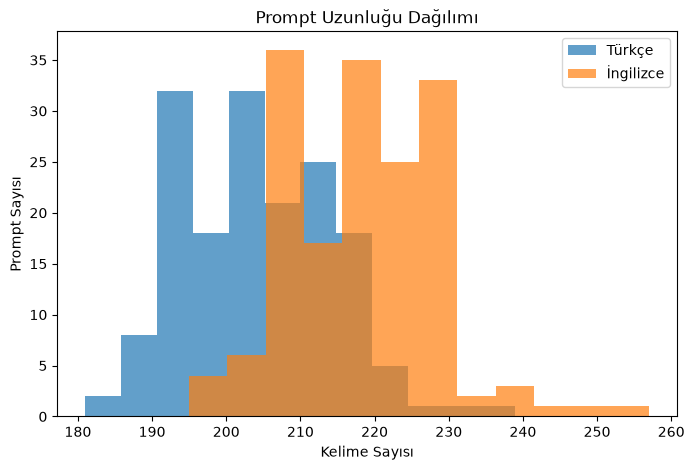

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    df["tr_word_count"],
    bins=12,
    alpha=0.7,
    label="Türkçe"
)

plt.hist(
    df["en_word_count"],
    bins=12,
    alpha=0.7,
    label="İngilizce"
)

plt.xlabel("Kelime Sayısı")

plt.ylabel("Prompt Sayısı")

plt.title("Prompt Uzunluğu Dağılımı")

plt.legend()

plt.show()

# En Uzun Promptlar

In [54]:
df.nlargest(

    5,

    "tr_word_count"

)[

    [

        "file_name",

        "tr_word_count"

    ]

]

,file_name,tr_word_count
49,CHRD_REAL_0065.jpeg,239
63,CHRD_REAL_0080.jpeg,233
0,CHRD_REAL_0001.jpeg,228
29,CHRD_REAL_0042.jpeg,223
38,CHRD_REAL_0051.jpeg,223


# En Kısa Promptlar

In [55]:
df.nsmallest(

    5,

    "tr_word_count"

)[

    [

        "file_name",

        "tr_word_count"

    ]

]

,file_name,tr_word_count
145,CHRD_REAL_0170.jpeg,181
89,CHRD_REAL_0109.jpeg,185
54,CHRD_REAL_0071.jpeg,186
100,CHRD_REAL_0121.jpeg,186
123,CHRD_REAL_0146.jpeg,187


# Tema Bazında Ortalama Prompt Uzunluğu

In [56]:
theme_stats = (

    df

    .groupby("theme")["tr_word_count"]

    .mean()

    .sort_values(ascending=False)

)

theme_stats

theme
Rock-cut Heritage     212.148148
Village Square        211.500000
Daily Life            204.351351
Local Architecture    201.960784
Natural Landscape     199.650000
Fairy Chimney         191.090909
Name: tr_word_count, dtype: float64

# Tema Bazında Grafik

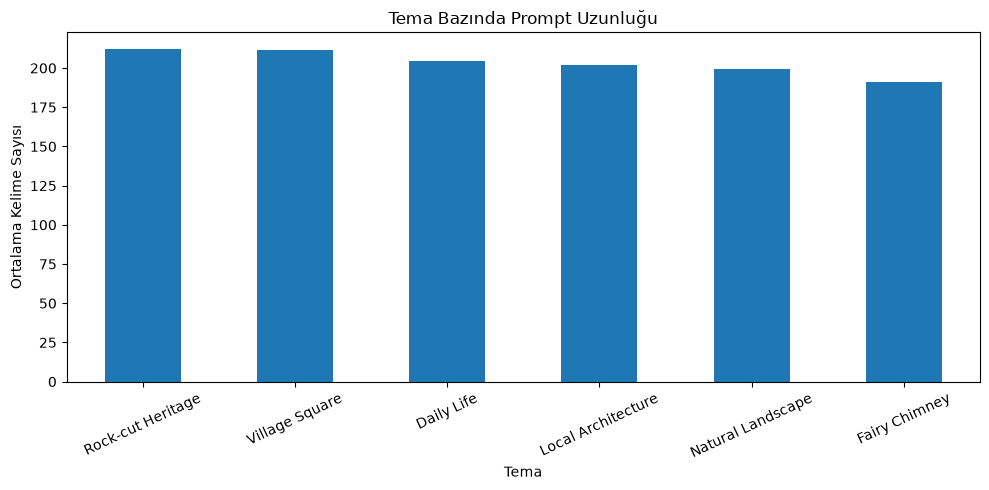

In [57]:
plt.figure(figsize=(10,5))

theme_stats.plot(kind="bar")

plt.ylabel("Ortalama Kelime Sayısı")

plt.xlabel("Tema")

plt.title("Tema Bazında Prompt Uzunluğu")

plt.xticks(rotation=25)

plt.tight_layout()

plt.show()

# Prompt Kalite Özeti

In [58]:
summary = pd.DataFrame({

    "Toplam Prompt":[len(df)],

    "TR Ortalama Kelime":[round(df["tr_word_count"].mean(),1)],

    "EN Ortalama Kelime":[round(df["en_word_count"].mean(),1)],

    "Tema Sayısı":[df["theme"].nunique()],

    "Motif Sayısı":[
        pd.concat(
            [df["motif_1"], df["motif_2"]]
        ).nunique()
    ]

})

summary

,Toplam Prompt,TR Ortalama Kelime,EN Ortalama Kelime,Tema Sayısı,Motif Sayısı
0,164,204.2,218.3,6,30


# Sonuçların Kaydedilmesi

In [59]:
stats.to_csv(

    "../results/prompt_statistics.csv",

    encoding="utf-8-sig"

)

summary.to_csv(

    "../results/prompt_summary.csv",

    encoding="utf-8-sig"

)

print("Prompt istatistikleri kaydedildi.")

Prompt istatistikleri kaydedildi.
